In [5]:
import os
os.chdir("/home/philbou/projects/def-rfajber/philbou/abstractEGU")
import composite as c

In [2]:
import xarray as xr 
ds = xr.open_mfdataset("/home/philbou/scratch/isca_data/RT42_sst_0_bucket/run0506/page_shape_atmos_monthly.nc")

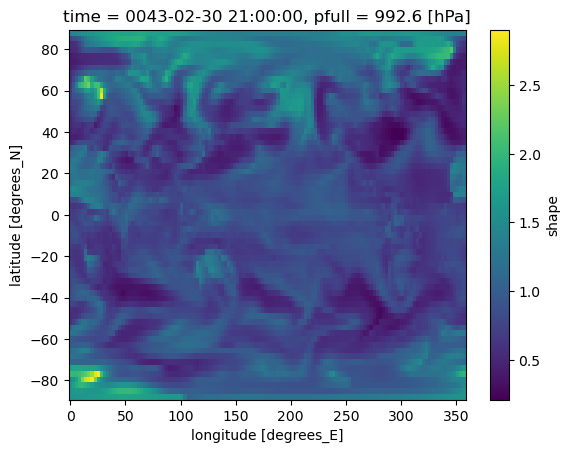

In [3]:
ds.shape.isel(time = -1,pfull = -1).plot()

In [4]:

import xarray as xr
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy
cartopy.config['pre_existing_data_dir'] = '/home/philbou/miniconda3/envs/pro_env/share/cartopy'
cartopy.config['data_dir'] = '/home/philbou/miniconda3/envs/pro_env/share/cartopy'

def select_region3D(ds, lat_range, lon_range, pfull_range):
    region = ds.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1]),
        lat_interp=slice(lat_range[0], lat_range[1]),
        pfull=slice(pfull_range[0], pfull_range[1])    
        #phalf=slice(pfull_range[0], pfull_range[1])
    )
    return region
    
def select_region3D_full(ds, lat_range, lon_range, pfull_range):
    region = ds.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1]),
        pfull=slice(pfull_range[0], pfull_range[1]),    
        phalf=slice(pfull_range[0], pfull_range[1])
    )
    return region
def select_region2D(ds, lat_range, lon_range):
    region = ds.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1])
    )
    return region

In [12]:
zones = {
    "NA": {
        "ID": "NA",
        "long_name": "Inland North America",
        "lon_edges": (240, 280),
        "lat_edges": (30, 60),
        "lon_edges_": (-120, -80),
        "lat_edges_": (30, 60),
        "center_lon": [260],
        "center_lat": [45],
        "color": "yellow"
    },
    "NATL": {
        "ID": "NATL",
        "long_name": "North Atlantic",
        "lon_edges": (280, 360),
        "lat_edges": (30, 60),
        "lon_edges_": (-80, 0),
        "lat_edges_": (30, 60),
        "center_lon": [320],
        "center_lat": [45],
        "color": "dodgerblue"
    },
    "EU": {
        "ID": "EU",
        "long_name": "Europe",
        "lon_edges": (0, 50),
        "lat_edges": (30, 60),
        "lon_edges_": (0, 50),
        "lat_edges_": (30, 60),
        "center_lon": [25],
        "center_lat": [45],
        "color": "blue"
    },
    "CA": {
        "ID": "CA",
        "long_name": "Central Asia",
        "lon_edges": (50, 120),
        "lat_edges": (30, 60),
        "lon_edges_": (50, 120),
        "lat_edges_": (30, 60),
        "center_lon": [85],
        "center_lat": [45],
        "color": "red"
    },
    "NPO": {
        "ID": "NPO",
        "long_name": "North Pacific",
        "lon_edges": (120, 240),
        "lat_edges": (30, 60),
        "lon_edges_": (120, -120),
        "lat_edges_": (30, 60),
        "center_lon": [150, 210],
        "center_lat": [45, 45],
        "color": "green"
    },
    "TA": {
        "ID": "TA",
        "long_name": "Tropical Atlantic",
        "lon_edges": (280, 30),
        "lat_edges": (90-30, 30),
        "lon_edges_": (-80, 30),
        "lat_edges_": (-30, 30),
        "center_lon": [335],
        "center_lat": [90],
        "color": "pink"
    },
    "IO": {
        "ID": "IO",
        "long_name": "Indian Ocean",
        "lon_edges": (30, 120),
        "lat_edges": (90-30, 30),
        "lon_edges_": (30, 120),
        "lat_edges_": (-30, 30),
        "center_lon": [75],
        "center_lat": [90],
        "color": "orange"
    },
    "TPO": {
        "ID": "TPO",
        "long_name": "Tropical Pacific",
        "lon_edges": (120, 280),
        "lat_edges": (90-30, 30),
        "lon_edges_": (120, -80),
        "lat_edges_": (-30, 30),
        "center_lon": [150, 210],
        "center_lat": [90],
        "color": "lime"
    },
    "SO": {
        "ID": "SO",
        "long_name": "Southern Ocean",
        "lon_edges": (0, 360),
        "lat_edges": (90-60, 90-30),
        "lon_edges_": (-180, 180),
        "lat_edges_": (-60, -30),
        "center_lon": [0],
        "center_lat": [90-45],
        "color": "yellow"
    },
    "AR": {
        "ID": "AR",
        "long_name": "Arctic",
        "lon_edges": (0, 360),
        "lat_edges": (60, 90),
        "lon_edges_": (-180, 180),
        "lat_edges_": (60, 90),
        "center_lon": [0],
        "center_lat": [75],
        "color": "deepskyblue"
    },
    "ANT": {
        "ID": "ANT",
        "long_name": "Antarctic",
        "lon_edges": (0, 360),
        "lat_edges": (0, 30),
        "lon_edges_": (-180, 180),
        "lat_edges_": (-90, -60),
        "center_lon": [0],
        "center_lat": [90-75],
        "color": "lime"
    }
}

lon_midlat_points = np.array([25,85,312,345,153,226])
lat_midlat_points = 45*np.ones_like(lon_midlat_points)
from datetime import datetime

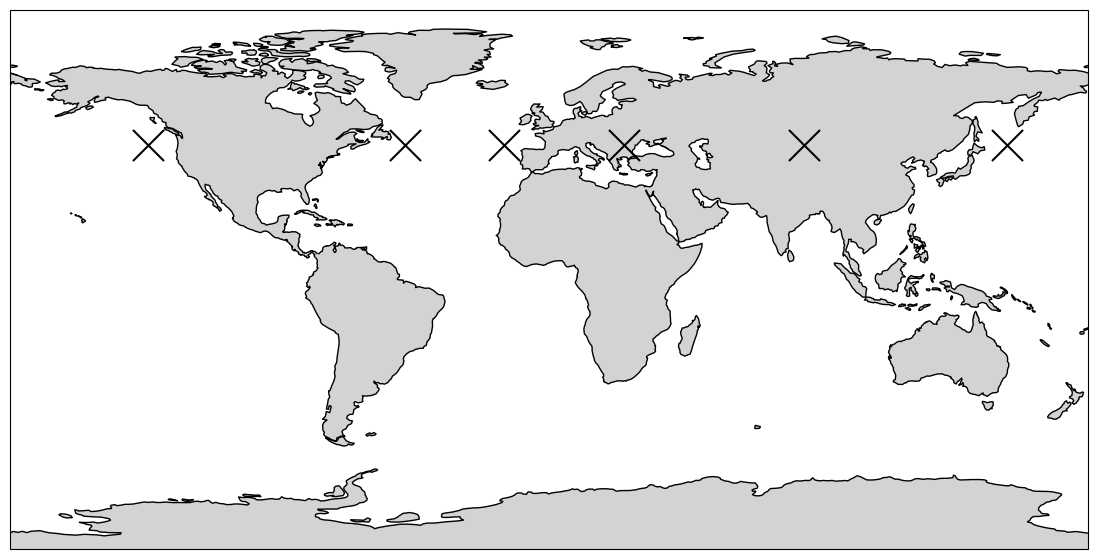

In [18]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

# Create figure
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
# Map features
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="lightgray")

ax.scatter(lon_midlat_points,lat_midlat_points,marker = "x",s = 500, color = "black")



plt.savefig("zones.png",dpi = 300)


In [1]:
import xarray as xr
ds = xr.open_dataset("/home/philbou/scratch/isca_data/RT42_sst_0_bucket/run0300/lon312.nc")

/home/philbou/miniconda3/envs/pro_env/lib/python3.12/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


In [6]:
c.get_composite_data(299)

Starting Month 299...


"Month 299: Failed ([Errno 2] No such file or directory: '/home/philbou/scratch/isca_data/RT42_sst_0_bucket/run0299/moist_data.nc')"